<a href="https://colab.research.google.com/github/mohammadayaanahsan/flyRank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadayaanahsan/flyRank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked actions + reason codes

Below, the final queue combines the Week-5 model's decline-risk
probability with the Week-4 baseline score into one ranked list,
with reason codes attached so a human reviewer understands why each
page is flagged.

In [1]:
!git clone https://github.com/mohammadayaanahsan/flyRank-internship.git
%cd flyRank-internship


Cloning into 'flyRank-internship'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 149 (delta 62), reused 95 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 1.87 MiB | 10.86 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/content/flyRank-internship


In [2]:
# If fresh session, run this first:
# !git clone https://github.com/mohammadayaanahsan/flyRank-internship.git
# %cd flyRank-internship

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].drop_duplicates(subset="content_id").reset_index(drop=True)

y = (df["trend_direction"] == "down").astype(int)
num_features = ["content_age_days", "days_since_last_update", "impressions_90d",
                 "avg_position", "ctr", "word_count"]
X = df[num_features].replace([np.inf, -np.inf], np.nan).fillna(0)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])

df["model_probability"] = rf.predict_proba(X)[:, 1]

def normalize(s):
    s = s.replace([np.inf, -np.inf], np.nan).fillna(0)
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s * 0

visibility_score = normalize(df["impressions_90d"])
freshness_risk_score = normalize(df["days_since_last_update"])
position_opportunity_score = normalize(-df["avg_position"].fillna(df["avg_position"].max()))
depth_gap_score = normalize(-df["word_count"].fillna(df["word_count"].max()))
baseline_score = (0.40*visibility_score + 0.30*freshness_risk_score
                   + 0.25*position_opportunity_score + 0.05*depth_gap_score)

df["final_score"] = 100 * (0.70 * df["model_probability"] + 0.30 * baseline_score)

def reason_codes(row):
    codes = []
    if row["model_probability"] >= 0.65:
        codes.append("model_decline_risk")
    if row["model_probability"] >= 0.50 and row["impressions_90d"] >= 500:
        codes.append("visible_model_opportunity")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        codes.append("ctr_review_candidate")
    return ",".join(codes) if codes else "low_confidence"

df["reason_codes"] = df.apply(reason_codes, axis=1)

ranked_queue = df.sort_values("final_score", ascending=False)

os.makedirs("work/outputs", exist_ok=True)
ranked_queue.to_csv("work/outputs/final_action_queue.csv", index=False)

print(f"Ranked {len(ranked_queue)} pages into final action queue.")
print(ranked_queue[["content_id", "final_score", "reason_codes", "model_probability"]].head(15))

Ranked 30000 pages into final action queue.
                 content_id  final_score  \
7452   content_72496874f806    82.014251   
28154  content_4d76cdb3387b    81.203143   
13409  content_4e658a59c333    81.196026   
21595  content_bd823d21e6a4    81.177545   
3019   content_d333007c70d9    81.169956   
13854  content_9a8f08a47294    81.147898   
4692   content_a10924bced3d    81.133227   
12516  content_9d4e9f7b6e58    81.115121   
7925   content_aa8c0ad3a60b    81.106856   
7948   content_9b03dbbf0470    81.077962   
15968  content_66b4046cc144    81.070774   
16883  content_d6570c51c9bd    81.027692   
24999  content_f30d30832c2d    81.018505   
22415  content_a95a24bd6507    81.012266   
1924   content_f1cdef315047    80.960441   

                                            reason_codes  model_probability  
7452   model_decline_risk,visible_model_opportunity,c...              0.945  
28154  model_decline_risk,visible_model_opportunity,c...              1.000  
13409            

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits

Who uses this: a content team lead or SEO reviewer with limited
review capacity per week (e.g. reviewing 20-50 pages).

What for: deciding which pages to open and inspect first for
potential refresh, expansion, or protection - not an automatic
refresh trigger.

Where it stops being valid: this queue should not be used to make
automated changes without human review, should not be trusted beyond
this starter sample's scope (~30K anonymized pages, one client
portfolio slice), and should not be re-used on data older than the
90-day window it was built from without re-running the pipeline.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human review + the no-go list

Before acting, a person must check: does this page's decline overlap
with a sibling page absorbing the traffic (consolidation)? Is the
drop seasonal rather than structural? Is there enough volume
(impressions/sessions) that this isn't just noise?

Never automate: publishing content changes directly from the model
score, removing/redirecting a page based solely on this score, or
treating "model_decline_risk" as proof a page will definitely keep
declining without a human first opening the page.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / retrain triggers

Signs the recommendations have gone stale: Precision@50 on new data
drops noticeably below what was measured here; the review team
reports the top-ranked pages "don't look right" on manual spot-check;
the underlying trend_direction distribution shifts significantly
(e.g. a much higher or lower base rate of decline than seen in this
sample); or more than ~90 days pass since the model was last trained,
since the data window itself is time-bound.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the paper

Below, the queue and a summary chart are saved to work/outputs/ for
reuse in the capstone paper.

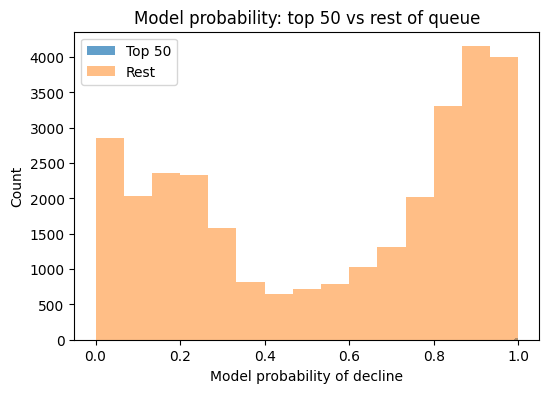

Saved: work/outputs/final_action_queue.csv
Saved: work/outputs/charts/top50_vs_rest.png


In [3]:
import matplotlib.pyplot as plt

# Already saved: work/outputs/final_action_queue.csv

# Quick chart: model probability distribution for top 50 vs rest
plt.figure(figsize=(6,4))
plt.hist(ranked_queue.head(50)["model_probability"], bins=15, alpha=0.7, label="Top 50")
plt.hist(ranked_queue.iloc[50:]["model_probability"], bins=15, alpha=0.5, label="Rest")
plt.xlabel("Model probability of decline")
plt.ylabel("Count")
plt.legend()
plt.title("Model probability: top 50 vs rest of queue")
os.makedirs("work/outputs/charts", exist_ok=True)
plt.savefig("work/outputs/charts/top50_vs_rest.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: work/outputs/final_action_queue.csv")
print("Saved: work/outputs/charts/top50_vs_rest.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.